In [ ]:
import pandas as pd
import numpy as np

# Load the dataset
heart_failure=pd.read_csv("/content/sample_data/heart.csv")

In [ ]:
heart_failure.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [ ]:
#Feature Engineering Steps
# Converting 'Sex and ST_Slope' column to numerical values
sex_num = {'M': 0, 'F':1}
heart_failure['Sex'] = heart_failure['Sex'].map(sex_num)
St={'Up': 0, 'Flat':1,'Down':2}
heart_failure['ST_Slope']=heart_failure['ST_Slope'].map(St)
EA={'N':0,'Y':1}
heart_failure['ExerciseAngina']=heart_failure['ExerciseAngina'].map(EA)
heart_failure.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,ATA,140,289,0,Normal,172,0,0.0,0,0
1,49,1,NAP,160,180,0,Normal,156,0,1.0,1,1
2,37,0,ATA,130,283,0,ST,98,0,0.0,0,0
3,48,1,ASY,138,214,0,Normal,108,1,1.5,1,1
4,54,0,NAP,150,195,0,Normal,122,0,0.0,0,0


In [ ]:
# Droping 'ChestPainType & RestingECG' columns
heart_failure.drop(['ChestPainType','RestingECG'],axis=1,inplace=True)

In [ ]:
heart_failure.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,140,289,0,172,0,0.0,0,0
1,49,1,160,180,0,156,0,1.0,1,1
2,37,0,130,283,0,98,0,0.0,0,0
3,48,1,138,214,0,108,1,1.5,1,1
4,54,0,150,195,0,122,0,0.0,0,0


In [ ]:
#checking if there are any null values.
heart_failure.isnull().sum()

Age               0
Sex               0
RestingBP         0
Cholesterol       0
FastingBS         0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [ ]:
#Seperate the Features and label or Target variable

X = heart_failure.drop('HeartDisease', axis=1)
y = heart_failure['HeartDisease']

In [ ]:
from sklearn.model_selection import train_test_split #importing the function from sklearn library.

In [ ]:
#Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=87)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
#Standardising the data
scaler= StandardScaler()
# Fitting on training set.
scaler.fit(X_train)
# Apply transform to both the training set and the test set.
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
#Creating an instance for LogisticRegression
LR=LogisticRegression()

In [ ]:
#Define hyperparameter for logistic regression
LR_Params = {
    'C': [0.1, 1, 10],   # Regularization parameter
    'max_iter': [100, 200, 300],  # Maximum number of iterations
    'solver': ['liblinear', 'saga', 'lbfgs']  # Algorithm to use in optimization problem
}

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
#Perfomring GridSearchCV for logistic Regression
LR_grid=GridSearchCV(estimator=LR,param_grid=LR_Params,cv=5)

In [ ]:
LR_grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.1, 1, 10], 'max_iter': [100, 200, 300],
                         'solver': ['liblinear', 'saga', 'lbfgs']})

In [ ]:
#Print Best parameters,best Score and best estimator for logistic regressoin
print("LR-Best Score:",LR_grid.best_score_)
print("LR-Best Parameter:",LR_grid.best_params_)

LR-Best Score: 0.8393253191687633
LR-Best Parameter: {'C': 0.1, 'max_iter': 100, 'solver': 'liblinear'}


In [ ]:
LR=LogisticRegression(C=0.01,max_iter=100,solver='liblinear')

In [ ]:
#Fit the modle

In [ ]:
LR.fit(X_train,y_train)

LogisticRegression(C=0.01, solver='liblinear')

In [ ]:
#Give predictions
y_pred=LR.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix
#Calculate the confusion matrix
CNM=confusion_matrix(y_test,y_pred)

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

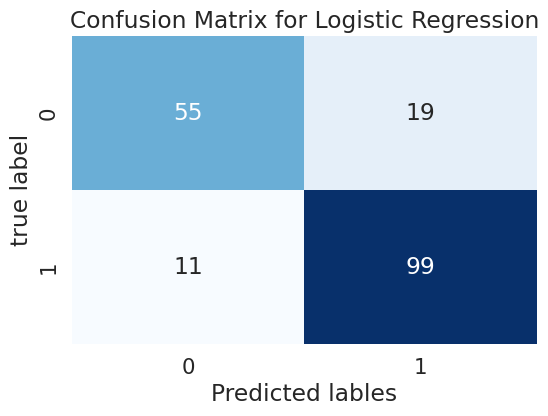

In [ ]:
#plot the  confusion matrix for Regressoin Model
plt.figure(figsize=(6, 4))
sns.set(font_scale=1.4)
sns.heatmap(CNM, annot=True, fmt="g", cmap="Blues",cbar=False)
plt.xlabel('Predicted lables')
plt.ylabel('true label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [ ]:
best_model=LR_grid.best_estimator_

In [ ]:
best_model.predict(X_test)

array([1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0,
       1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 0, 0])

In [ ]:
means=LR_grid.cv_results_['mean_test_score']
stds=LR_grid.cv_results_['std_test_score']
for mean,std,params in zip(means,stds,LR_grid.cv_results_['params']):
  print('{} (+/-{}) for {}'.format(round(mean,3), round(std*2, 3), params))

0.839 (+/-0.079) for {'C': 0.1, 'max_iter': 100, 'solver': 'liblinear'}
0.838 (+/-0.077) for {'C': 0.1, 'max_iter': 100, 'solver': 'saga'}
0.838 (+/-0.077) for {'C': 0.1, 'max_iter': 100, 'solver': 'lbfgs'}
0.839 (+/-0.079) for {'C': 0.1, 'max_iter': 200, 'solver': 'liblinear'}
0.838 (+/-0.077) for {'C': 0.1, 'max_iter': 200, 'solver': 'saga'}
0.838 (+/-0.077) for {'C': 0.1, 'max_iter': 200, 'solver': 'lbfgs'}
0.839 (+/-0.079) for {'C': 0.1, 'max_iter': 300, 'solver': 'liblinear'}
0.838 (+/-0.077) for {'C': 0.1, 'max_iter': 300, 'solver': 'saga'}
0.838 (+/-0.077) for {'C': 0.1, 'max_iter': 300, 'solver': 'lbfgs'}
0.839 (+/-0.075) for {'C': 1, 'max_iter': 100, 'solver': 'liblinear'}
0.839 (+/-0.075) for {'C': 1, 'max_iter': 100, 'solver': 'saga'}
0.839 (+/-0.075) for {'C': 1, 'max_iter': 100, 'solver': 'lbfgs'}
0.839 (+/-0.075) for {'C': 1, 'max_iter': 200, 'solver': 'liblinear'}
0.839 (+/-0.075) for {'C': 1, 'max_iter': 200, 'solver': 'saga'}
0.839 (+/-0.075) for {'C': 1, 'max_iter': 2

In [ ]:
#Random forest Cassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#create an instance of the RF
RF = RandomForestClassifier()

RF_params= { #Hyperparameters for random forest
    'n_estimators': [5, 20, 40, 80, 100],
    'max_depth': [2, 5, 10, None],
    'min_samples_split': [2, 3, 5],
    'criterion':['gini', 'entropy', 'log_loss']
}

In [ ]:
#Perform GridSearchCV for Random Forest Classifier
RF_grid=GridSearchCV(estimator=RF,param_grid=RF_params,cv=5)

In [ ]:
RF_grid.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'criterion': ['gini', 'entropy', 'log_loss'],
                         'max_depth': [2, 5, 10, None],
                         'min_samples_split': [2, 3, 5],
                         'n_estimators': [5, 20, 40, 80, 100]})

In [ ]:
#Print the RF results
print("RF-Best Parameters:",RF_grid.best_params_)
print("RF-Best Score:",RF_grid.best_score_)

RF-Best Parameters: {'criterion': 'log_loss', 'max_depth': 10, 'min_samples_split': 3, 'n_estimators': 40}
RF-Best Score: 0.8665548411145281


In [ ]:
#initialize Randomforect calssifier with best parameter

In [ ]:
RF=RandomForestClassifier(criterion='entropy',max_depth=8,min_samples_split=3,n_estimators=100)

In [ ]:
#Fit the model
RF.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', max_depth=8, min_samples_split=3)

In [ ]:
#Make predict
y_pred_RF=RF.predict(X_test)

In [ ]:
#calculate the confustion matrix
CNM_RF=confusion_matrix(y_test,y_pred_RF)

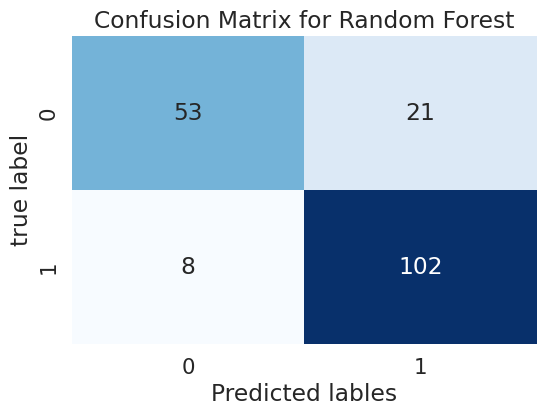

In [ ]:
#plot the  confusion matrix for Regressoin Model
plt.figure(figsize=(6, 4))
sns.set(font_scale=1.4)
sns.heatmap(CNM_RF, annot=True, fmt="g", cmap="Blues",cbar=False)
plt.xlabel('Predicted lables')
plt.ylabel('true label')
plt.title('Confusion Matrix for Random Forest')
plt.show()

In [ ]:
best_model=RF_grid.best_estimator_

In [ ]:
best_model.predict(X_test)

array([1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0,
       0, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1,
       1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 1])

In [ ]:
means=RF_grid.cv_results_['mean_test_score']
stds=RF_grid.cv_results_['std_test_score']
for mean,std,params in zip(means,stds,RF_grid.cv_results_['params']):
  print('{} (+/-{}) for {}'.format(round(mean,3), round(std*2, 3), params))

0.83 (+/-0.036) for {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 5}
0.842 (+/-0.036) for {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 20}
0.822 (+/-0.049) for {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 40}
0.831 (+/-0.037) for {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 80}
0.835 (+/-0.031) for {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 2, 'n_estimators': 100}
0.826 (+/-0.059) for {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 3, 'n_estimators': 5}
0.831 (+/-0.043) for {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 3, 'n_estimators': 20}
0.832 (+/-0.041) for {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 3, 'n_estimators': 40}
0.832 (+/-0.029) for {'criterion': 'gini', 'max_depth': 2, 'min_samples_split': 3, 'n_estimators': 80}
0.838 (+/-0.038) for {'criterion': 'gini', 'max_depth': 2, 'min_samples_spl